# Qwen3

In [1]:
GROUP_NAME = "Qwen3-VL-30B-A3B-Instruct-gaze2"
RESULT_PATH = "../output/result_1766691418_20251124F_20260101F_20251123_20251124.csv"

## Setup

In [2]:
options(warn=0, error=recover)
install_if_missing <- function(pkg, github = NULL) {
  if (!requireNamespace(pkg, quietly = TRUE)) {
    message(sprintf("Installing package: %s", pkg))
    tryCatch({
      if (is.null(github)) {
        install.packages(pkg, repos = "https://cloud.r-project.org")
      } else {
        if (!requireNamespace("remotes", quietly = TRUE)) {
          install.packages("remotes", repos = "https://cloud.r-project.org")
        }
        remotes::install_github(github)
      }
    }, error = function(e) {
      message(sprintf("Failed to install %s: %s", pkg, e$message))
      return(NULL)
    })
  }
  if (requireNamespace(pkg, quietly = TRUE)) {
    library(pkg, character.only = TRUE)
  } else {
    message(sprintf("Package %s is still not available after attempted installation.", pkg))
  }
}
pkgs <- c("lme4","readr","marginaleffects","ggplot2","dplyr","parameters", "performance", "tidyr", "car")
for (pkg in pkgs) {
  install_if_missing(pkg)
}
install_if_missing("ggeffects", "strengejacke/ggeffects")

utils:::print.sessionInfo(sessionInfo()[-c(10,12,13)])

Loading required package: Matrix


Attaching package: ‘marginaleffects’


The following object is masked from ‘package:lme4’:

    refit



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘tidyr’


The following objects are masked from ‘package:Matrix’:

    expand, pack, unpack


Loading required package: carData


Attaching package: ‘car’


The following object is masked from ‘package:dplyr’:

    recode




R version 4.4.3 (2025-02-28)
Platform: aarch64-apple-darwin20.0.0
Running under: macOS Sequoia 15.6.1

Matrix products: default


locale:
[1] C/C.UTF-8/C/C/C/C

time zone: Asia/Shanghai
tzcode source: system (macOS)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
 [1] ggeffects_2.3.2        car_3.1-3              carData_3.0-5         
 [4] tidyr_1.3.2            performance_0.15.3     parameters_0.28.3     
 [7] dplyr_1.1.4            ggplot2_4.0.1          marginaleffects_0.31.0
[10] readr_2.1.6            lme4_1.1-38            Matrix_1.7-4          


In [3]:
df <- read_csv(RESULT_PATH, na = "", show_col_types = FALSE, col_types = cols(
    Stimulus_ID = col_factor(),
    Prompt_ID = col_factor()))
df <- df[df$Group == GROUP_NAME, ]
df$offset_accuracy <- qlogis(1 / df$n_candidates)
df$offset_wrongness <- qlogis(df$Wrongness_exp / df$Wrongness_max)
df$ActorSite <- interaction(df$Actor, df$Site, drop = TRUE)
df$Proximity_c <- scale(df$Proximity, scale = FALSE) # taking subset almost does not change the mean
df$n_candidates_c <- scale(df$n_candidates, scale = FALSE) # taking subset almost does not change the mean
strict_control <- glmerControl(optimizer = "bobyqa", optCtrl = list(maxfun = 2e5))

## On Stimuli B (Hypothesis-Driven)

In [4]:
df_B <- df[df$Site != "Site0", ] # take Stimuli B results only
df_B$Condition <- factor(ifelse(is.na(df_B$DistEyeHead), "natural", ifelse(df_B$DistEyeHead == 0, "congruent", "incongruent")), levels = c("natural", "congruent", "incongruent"))
df_unnatural <- df_B %>%
  filter(Condition %in% c("congruent", "incongruent")) %>% 
  mutate(offset_wrongness_head = qlogis(ExpectedDistToHeadTarget / MaxDistToHeadTarget),)
df_replicate <- df_B[df_B$Condition != "incongruent", ]

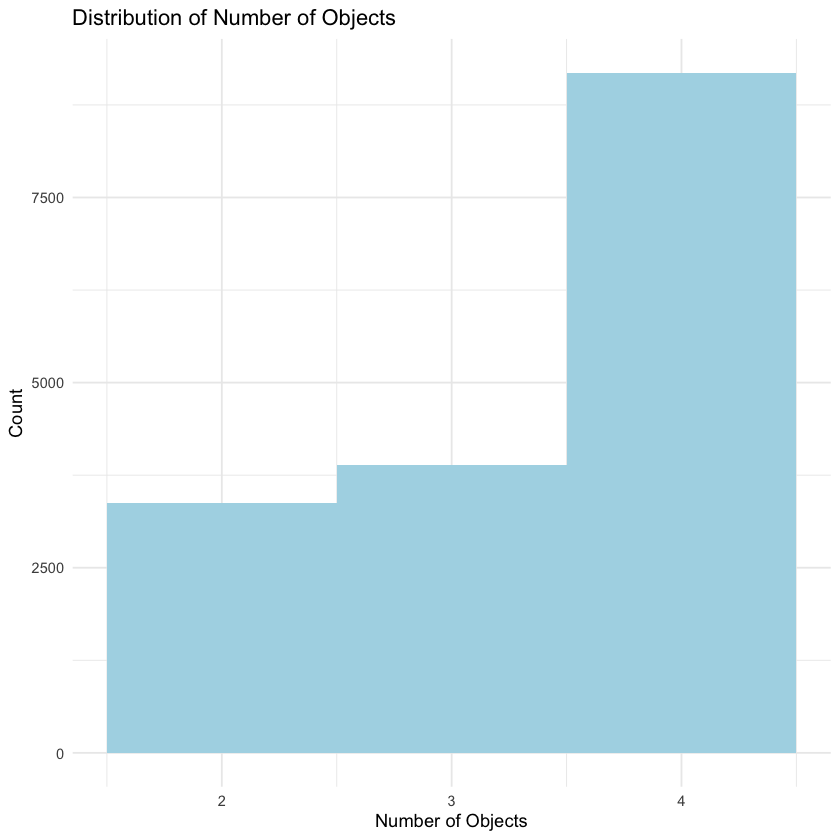

In [5]:
ggplot(df_unnatural, aes(x = n_candidates)) +
    geom_histogram(binwidth = 1, fill = "lightblue") +
    theme_minimal() +
    labs(
        title = "Distribution of Number of Objects",
        x = "Number of Objects",
        y = "Count"
    )

### Replicating the Proximity effect and the (lack of) View effect

In [7]:
m_effects1 <- glmer(Accuracy ~ scale(Proximity, scale=FALSE) * Angle * scale(n_candidates, scale = FALSE) * Condition + offset(offset_accuracy) + (1 | Stimulus_ID) + (1 | Candidates) + (1 | Prompt_ID), data = df_replicate, family = binomial, control = strict_control)

In [8]:
isSingular(m_effects1)

[1] TRUE

In [11]:
m_effects2 <- glmer(Accuracy ~ scale(Proximity, scale=FALSE) * Angle * scale(n_candidates, scale = FALSE) * Condition + offset(offset_accuracy) + (1 | Stimulus_ID) + (1 | Prompt_ID), data = df_replicate, family = binomial, control = strict_control)
isSingular(m_effects2)

[1] FALSE

In [12]:
m_effects_c <- m_effects2

In [14]:
m_effects <- glmer(Accuracy ~ scale(Proximity, scale=FALSE) + Angle + scale(n_candidates, scale = FALSE) + Condition + offset(offset_accuracy) + (1 | Stimulus_ID) + (1 | Prompt_ID), data = df_replicate, family = binomial, control = strict_control)
anova(m_effects, m_effects_c)

,npar,AIC,BIC,logLik,-2*log(L),Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
m_effects,8,4717.152,4775.270,-2350.576,4701.152,NA,NA,NA
m_effects_c,26,4724.617,4913.503,-2336.309,4672.617,28.53441,18,0.05437461


In [15]:
avg_slopes(m_effects, variables = "Proximity")
avg_slopes(m_effects, variables = "n_candidates")
avg_comparisons(m_effects, variables = "Angle")

Warning message:
“For this model type, `marginaleffects` only takes into account the uncertainty in fixed-effect parameters. This is often appropriate when `re.form=NA`, but may be surprising to users who set `re.form=NULL` (default) or to some other value. Call `options(marginaleffects_safe = FALSE)` to silence this warning.”


term,contrast,estimate,std.error,statistic,p.value,s.value,conf.low,conf.high
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Proximity,dY/dX,-0.0357919,0.02710594,-1.320445,0.1866866,2.42131,-0.08891857,0.01733477


Warning message:
“For this model type, `marginaleffects` only takes into account the uncertainty in fixed-effect parameters. This is often appropriate when `re.form=NA`, but may be surprising to users who set `re.form=NULL` (default) or to some other value. Call `options(marginaleffects_safe = FALSE)` to silence this warning.”


term,contrast,estimate,std.error,statistic,p.value,s.value,conf.low,conf.high
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
n_candidates,dY/dX,-0.3048938,0.02949323,-10.33776,4.755328e-25,80.79866,-0.3626995,-0.2470882


Warning message:
“For this model type, `marginaleffects` only takes into account the uncertainty in fixed-effect parameters. This is often appropriate when `re.form=NA`, but may be surprising to users who set `re.form=NULL` (default) or to some other value. Call `options(marginaleffects_safe = FALSE)` to silence this warning.”


term,contrast,estimate,std.error,statistic,p.value,s.value,conf.low,conf.high
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Angle,left - front,0.04573348,0.05057347,0.9042977,0.36583755,1.450725,-0.05338871,0.1448557
Angle,right - front,0.11999812,0.04689784,2.5587134,0.01050603,6.572638,0.02808005,0.2119162


In [16]:
avg_slopes(m_effects_c, variables = "Proximity")
avg_slopes(m_effects_c, variables = "n_candidates")
avg_comparisons(m_effects_c, variables = "Angle")

Warning message:
“For this model type, `marginaleffects` only takes into account the uncertainty in fixed-effect parameters. This is often appropriate when `re.form=NA`, but may be surprising to users who set `re.form=NULL` (default) or to some other value. Call `options(marginaleffects_safe = FALSE)` to silence this warning.”


term,contrast,estimate,std.error,statistic,p.value,s.value,conf.low,conf.high
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Proximity,dY/dX,-0.02892383,0.03193935,-0.9055861,0.365155,1.453419,-0.0915238,0.03367614


Warning message:
“For this model type, `marginaleffects` only takes into account the uncertainty in fixed-effect parameters. This is often appropriate when `re.form=NA`, but may be surprising to users who set `re.form=NULL` (default) or to some other value. Call `options(marginaleffects_safe = FALSE)` to silence this warning.”


term,contrast,estimate,std.error,statistic,p.value,s.value,conf.low,conf.high
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
n_candidates,dY/dX,-0.2410608,0.03729294,-6.46398,1.019841e-10,33.19094,-0.3141536,-0.167968


Warning message:
“For this model type, `marginaleffects` only takes into account the uncertainty in fixed-effect parameters. This is often appropriate when `re.form=NA`, but may be surprising to users who set `re.form=NULL` (default) or to some other value. Call `options(marginaleffects_safe = FALSE)` to silence this warning.”


term,contrast,estimate,std.error,statistic,p.value,s.value,conf.low,conf.high
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Angle,left - front,0.05269436,0.06365748,0.8277796,0.407795305,1.294083,-0.07207200,0.1774607
Angle,right - front,0.20184669,0.06315084,3.1962632,0.001392201,9.488417,0.07807333,0.3256201


In [19]:
### Report
summary(m_effects)
Anova(m_effects, type = 3)
vc_list <- lapply(VarCorr(m_effects), function(x) attr(x, "stddev")^2)
vc <- sum(unlist(vc_list))
effect_size_denom_t <- sqrt(vc + pi^2/3)

res <- summary(m_effects)$coefficients
res <- as.data.frame(res)
res <- cbind(term = rownames(res), res)
rownames(res) <- NULL
res$`Pr(>|z|)` <- format(res$`Pr(>|z|)`, scientific = FALSE)
res$CI_low <- res$Estimate - 1.96 * res$`Std. Error`
res$CI_high <- res$Estimate + 1.96 * res$`Std. Error`
res$effect_size_denom <- effect_size_denom_t
res$effect_size <- res$Estimate / effect_size_denom_t
res

# The below code is for generating the table in the paper.
stim_id_var_val <- if (!is.null(vc_list$Stimulus_ID) && length(vc_list$Stimulus_ID) > 0) vc_list$Stimulus_ID[[1]] else NA_real_
prompt_id_var_val <- if (!is.null(vc_list$Prompt_ID) && length(vc_list$Prompt_ID) > 0) vc_list$Prompt_ID[[1]] else NA_real_
participant_id_var_val <- if (!is.null(vc_list$Participant_ID) && length(vc_list$Participant_ID) > 0) vc_list$Participant_ID[[1]] else NA_real_

intercept_est <- res[res$term == "(Intercept)", "Estimate"]
intercept_se <- res[res$term == "(Intercept)", "Std. Error"]

angleleft_est <- res[res$term == "Angleleft", "Estimate"]
angleleft_se <- res[res$term == "Angleleft", "Std. Error"]
angleleft_p_val <- res[res$term == "Angleleft", "Pr(>|z|)"]
angleleft_eff_size <- res[res$term == "Angleleft", "effect_size"]

angleright_est <- res[res$term == "Angleright", "Estimate"]
angleright_se <- res[res$term == "Angleright", "Std. Error"]
angleright_p_val <- res[res$term == "Angleright", "Pr(>|z|)"]
angleright_eff_size <- res[res$term == "Angleright", "effect_size"]

proximity_term_name <- "scale(Proximity, scale = FALSE)"
if (!proximity_term_name %in% res$term) {
    proximity_term_name <- grep("Proximity", res$term, value = TRUE)[1]
}
proximity_est <- res[res$term == proximity_term_name, "Estimate"]
proximity_se <- res[res$term == proximity_term_name, "Std. Error"]
proximity_p_val <- res[res$term == proximity_term_name, "Pr(>|z|)"]
proximity_eff_size <- res[res$term == proximity_term_name, "effect_size"]

n_candidates_term_name <- "scale(n_candidates, scale = FALSE)"
if (!n_candidates_term_name %in% res$term) {
    n_candidates_term_name <- grep("n_candidates", res$term, value = TRUE)[1]
}
n_obj_est <- res[res$term == n_candidates_term_name, "Estimate"]
n_obj_se <- res[res$term == n_candidates_term_name, "Std. Error"]
n_obj_p_val <- res[res$term == n_candidates_term_name, "Pr(>|z|)"]
n_obj_eff_size <- res[res$term == n_candidates_term_name, "effect_size"]

#actory_term_name <- "ActorY" # Assuming 'X' is the reference level for Actor factor
#actory_est <- res[res$term == actory_term_name, "Estimate"]
#actory_se <- res[res$term == actory_term_name, "Std. Error"]
#actory_p_val <- res[res$term == actory_term_name, "Pr(>|z|)"]
#actory_eff_size <- res[res$term == actory_term_name, "effect_size"]

# Prepare data for data frame
table_data <- list(
    c("StimulusID", "Variance", sprintf("%.7f", stim_id_var_val)),
    c("ParticipantID", "Variance", sprintf("%.7f", participant_id_var_val)),
    c("PromptID", "Variance", sprintf("%.7f", prompt_id_var_val)),
    c("Effect Size Denom", "", sprintf("%.7f", effect_size_denom_t)),

    c("Intercept", "b", sprintf("%.7f", intercept_est)),
    c("", "SE", sprintf("%.7f", intercept_se)),

    c("View=left", "b", sprintf("%.7f", angleleft_est)),
    c("", "SE", sprintf("%.7f", angleleft_se)),
    c("", "p", sprintf("%.7f", as.numeric(angleleft_p_val))),
    c("", "Effect size", sprintf("%.7f", angleleft_eff_size)),

    c("View=right", "b", sprintf("%.7f", angleright_est)),
    c("", "SE", sprintf("%.7f", angleright_se)),
    c("", "p", sprintf("%.7f", as.numeric(angleright_p_val))),
    c("", "Effect size", sprintf("%.7f", angleright_eff_size)),

    c("Proximity", "b", sprintf("%.7f", proximity_est)),
    c("", "SE", sprintf("%.7f", proximity_se)),
    c("", "p", sprintf("%.7f", as.numeric(proximity_p_val))),
    c("", "Effect size", sprintf("%.7f", proximity_eff_size)),

    c("#Object", "b", sprintf("%.7f", n_obj_est)),
    c("", "SE", sprintf("%.7f", n_obj_se)),
    c("", "p", sprintf("%.7f", as.numeric(n_obj_p_val))),
    c("", "Effect size", sprintf("%.7f", n_obj_eff_size))

    #c("ActorY", "b", sprintf("%.7f", actory_est)),
    #c("", "SE", sprintf("%.7f", actory_se)),
    #c("", "p", sprintf("%.7f", as.numeric(actory_p_val))),
    #c("", "Effect size", sprintf("%.7f", actory_eff_size))
)

# Convert to data frame
df_output <- do.call(rbind, lapply(table_data, function(x) data.frame(V1=x[1], V2=x[2], V3=x[3], stringsAsFactors=FALSE)))

# Print only the third column for easy copy-pasting to Excel
write.table(df_output[,3, drop=FALSE], file="", sep = "\t", row.names = FALSE, col.names = FALSE, quote = FALSE)

Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: binomial  ( logit )
Formula: cbind(Wrongness, Wrongness_max - Wrongness) ~ scale(Proximity,  
    scale = FALSE) + Angle + scale(n_candidates, scale = FALSE) +  
    Condition + offset(offset_wrongness) + (1 | Stimulus_ID)
   Data: df_replicate
Control: strict_control

      AIC       BIC    logLik -2*log(L)  df.resid 
  10451.3   10502.2   -5218.7   10437.3     10553 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-3.4463 -0.1305 -0.0007  0.1464  3.7878 

Random effects:
 Groups      Name        Variance Std.Dev.
 Stimulus_ID (Intercept) 15.48    3.935   
Number of obs: 10560, groups:  Stimulus_ID, 660

Fixed effects:
                                   Estimate Std. Error z value Pr(>|z|)  
(Intercept)                         -0.8178     0.3176  -2.575   0.0100 *
scale(Proximity, scale = FALSE)      0.4854     0.1987   2.442   0.0146 *
Angleleft                         

,Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>
(Intercept),6.6289741,1,0.01003330
"scale(Proximity, scale = FALSE)",5.9656561,1,0.01458717
Angle,5.0216256,2,0.08120221
"scale(n_candidates, scale = FALSE)",3.9072202,1,0.04807906
Condition,0.5459344,1,0.45998366


term,Estimate,Std. Error,z value,Pr(>|z|),CI_low,CI_high,effect_size_denom,effect_size
<chr>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),-0.8177551,0.3176143,-2.5746794,0.01003330,-1.440279122,-0.1952310,4.332897,-0.18873170
"scale(Proximity, scale = FALSE)",0.4853695,0.1987208,2.4424693,0.01458717,0.095876699,0.8748624,4.332897,0.11201963
Angleleft,0.3679685,0.3938594,0.9342636,0.35016791,-0.403995868,1.1399328,4.332897,0.08492435
Angleright,-0.5253250,0.3949154,-1.3302215,0.18344531,-1.299359272,0.2487093,4.332897,-0.12124105
"scale(n_candidates, scale = FALSE)",0.3753784,0.1899046,1.9766690,0.04807906,0.003165511,0.7475914,4.332897,0.08663451
Conditioncongruent,-0.2390718,0.3235624,-0.7388738,0.45998366,-0.873254022,0.3951105,4.332897,-0.05517596


15.4841307
NA
NA
4.3328973
-0.8177551
0.3176143
0.3679685
0.3938594
0.3501679
0.0849243
-0.5253250
0.3949154
0.1834453
-0.1212410
0.4853695
0.1987208
0.0145872
0.1120196
0.3753784
0.1899046
0.0480791
0.0866345


### Test 2.1: Choose head targets more↑ often than gaze targets (when they differ).
Take results in the Incongruent Condition with #Objects greater than 2 and the responded object being either GazeTarget or HeadTarget. Fit a model with “IsHeadTarget ~ 1 + (1 | Objects) + (1 | StimulusID) + (1 | PromptID)” for each VLM. A significant positive intercept indicates a positive answer.

In [48]:
df_test21 <- df_B %>%
  filter(
    Condition == "incongruent",
    n_candidates > 2,
    (Choice == HeadTarget | Choice == label) # Keep only trials where the choice was one of the two cues
  )

mean(df_test21$IsHeadTarget)
stimulus_means <- df_test21 %>%
  group_by(Stimulus_ID) %>%
  summarize(prop_head = mean(IsHeadTarget))
t.test(stimulus_means$prop_head, mu = 0.5, alternative = "greater")

m_head_bias <- glmer(
  as.factor(IsHeadTarget) ~ 1 + (1 | Stimulus_ID) + (1 | Prompt_ID),
  data = df_test21, 
  family = binomial,
  control = strict_control
)
summary(m_head_bias)

[1] 0.5754349


	One Sample t-test

data:  stimulus_means$prop_head
t = 3.1802, df = 444, p-value = 0.0007873
alternative hypothesis: true mean is greater than 0.5
95 percent confidence interval:
 0.5338951       Inf
sample estimates:
mean of x 
0.5703645 


Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: binomial  ( logit )
Formula: as.factor(IsHeadTarget) ~ 1 + (1 | Stimulus_ID) + (1 | Prompt_ID)
   Data: df_test21
Control: strict_control

      AIC       BIC    logLik -2*log(L)  df.resid 
   2162.3    2182.2   -1078.1    2156.3      5631 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-4.1705 -0.0498  0.0049  0.0054  3.9460 

Random effects:
 Groups      Name        Variance  Std.Dev.
 Stimulus_ID (Intercept) 426.81008 20.6594 
 Prompt_ID   (Intercept)   0.05315  0.2305 
Number of obs: 5634, groups:  Stimulus_ID, 445; Prompt_ID, 16

Fixed effects:
            Estimate Std. Error z value Pr(>|z|)    
(Intercept)  10.3486     0.5129   20.18   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

In [41]:
stimulus_means <- df_test21 %>%
  group_by(Stimulus_ID) %>%
  summarize(n = sum(IsHeadTarget))
table(stimulus_means$n)


  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16 
153  22  14  13   6   7   9   9  11  13   8  11  11  13  14  22 109 

Conclusion: the model is not reliable (huge variance) because the data is bi-modal. Use t-test => positive.

In [94]:
mean(df_test21[df_test21$Proximity==1, ]$IsHeadTarget)
mean(df_test21[df_test21$Proximity==2, ]$IsHeadTarget)
mean(df_test21[df_test21$Proximity==3, ]$IsHeadTarget)

[1] 0.5824899

[1] 0.5705819

[1] 0.572697

In [ ]:
#plot(ggpredict(
#  m_head_bias, 
#  terms = c("DistEyeHead [all]", "Proximity [all]", "n_candidates [all]")
#))

ERROR: Error: Some of the specified `terms` were not found in the model.
  Maybe misspelled?


### Test 2.2: When head orientation is fixed but only eye appearance varies, responses stay the same much more often than chance?
Take results in the Congruent and Incongruent Conditions. Fix a combination of (#Objects, Objects, Proximity, View, HeadTarget, PromptID), vary only GazeTarget (2-4 levels). Calculate the number of combinations where the Choice stays the same. Compare the rate of such to chance using a directional one-sample t-test. Rejecting the null hypothesis indicates a positive answer.

In [49]:
df_test22 <- df_unnatural %>%
  group_by(Candidates, Proximity, Angle, n_candidates, HeadTarget, Prompt_ID) %>% 
  summarize(
    n_unique_answers = n_distinct(Choice),
    is_stable = if_else(n_distinct(Choice) == 1 & first(IsHeadTarget) == TRUE, 1, 0),
    n_gaze_target_levels = n(), 
    .groups = "drop"
  ) %>%
  mutate(
    # 3. Calculate Chance for this specific row
    chance_baseline = (1 / n_candidates) ^ (n_gaze_target_levels - 0)
  )

cat("Actual Stability Rate (choosing headtarget): ", mean(df_test22$is_stable), "\n")
cat("Random Chance Baseline:", mean(df_test22$chance_baseline), "\n")
diff_scores <- df_test22$is_stable - df_test22$chance_baseline
t.test(diff_scores, alternative = "greater")

Actual Stability Rate (choosing headtarget):  0.3338964 
Random Chance Baseline: 0.09560342 



	One Sample t-test

data:  diff_scores
t = 38.759, df = 5327, p-value < 2.2e-16
alternative hypothesis: true mean is greater than 0
95 percent confidence interval:
 0.2281785       Inf
sample estimates:
mean of x 
 0.238293 


In [50]:
df_test22 <- df_unnatural %>%
  group_by(Candidates, Proximity, Angle, n_candidates, HeadTarget, Prompt_ID) %>% 
  summarize(
    n_unique_answers = n_distinct(Choice),
    is_stable = if_else(n_distinct(Choice) == 1, 1, 0),
    n_gaze_target_levels = n(), 
    .groups = "drop"
  ) %>%
  mutate(
    # 3. Calculate Chance for this specific row
    chance_baseline = (1 / n_candidates) ^ (n_gaze_target_levels - 1)
  )

cat("Actual Stability Rate: ", mean(df_test22$is_stable), "\n")
cat("Random Chance Baseline:", mean(df_test22$chance_baseline), "\n")
diff_scores <- df_test22$is_stable - df_test22$chance_baseline
t.test(diff_scores, alternative = "greater")

Actual Stability Rate:  0.7081456 
Random Chance Baseline: 0.203735 



	One Sample t-test

data:  diff_scores
t = 80.641, df = 5327, p-value < 2.2e-16
alternative hypothesis: true mean is greater than 0
95 percent confidence interval:
 0.4941203       Inf
sample estimates:
mean of x 
0.5044107 


### Test 2.3: Performance when the HeadTarget = the GazeTarget is much higher↑ than when they differ?
Take results in the Congruent and Incongruent Conditions. Fit “IsCorrect ~ Proximity * View * #Object  * Condition + (1|Random Effects)” with offset being the chance accuracy. If the marginal prediction of Condition indicates that accuracy is higher in the congruent condition than in the incongruent condition, then this claim is supported.

In [51]:
mean(df_B[df_B$Condition == "congruent", ]$Accuracy)
mean(df_B[df_B$Condition == "incongruent", ]$Accuracy)

[1] 0.4409299

[1] 0.2764286

In [56]:
model_cond <- glmer(Accuracy ~ Proximity_c * Angle * n_candidates_c * Condition + offset(offset_accuracy) + (1|Stimulus_ID) + (1|Prompt_ID), data = df_unnatural, family = binomial, control = strict_control)
isSingular(model_cond)

[1] FALSE

In [58]:
avg_predictions(model_cond, variables = "Condition")

Warning message:
“For this model type, `marginaleffects` only takes into account the uncertainty in fixed-effect parameters. This is often appropriate when `re.form=NA`, but may be surprising to users who set `re.form=NULL` (default) or to some other value. Call `options(marginaleffects_safe = FALSE)` to silence this warning.”


Condition,estimate,std.error,statistic,p.value,s.value,conf.low,conf.high,df
<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
congruent,0.4221807,0.04270295,9.886453,4.766177e-23,74.15151,0.3384845,0.505877,Inf
incongruent,0.2456877,0.02723587,9.020738,1.868262e-19,62.21494,0.1923063,0.299069,Inf


In [59]:
avg_predictions(model_cond, variables = "Condition", hypothesis = ~ pairwise)

Warning message:
“For this model type, `marginaleffects` only takes into account the uncertainty in fixed-effect parameters. This is often appropriate when `re.form=NA`, but may be surprising to users who set `re.form=NULL` (default) or to some other value. Call `options(marginaleffects_safe = FALSE)` to silence this warning.”


hypothesis,estimate,std.error,statistic,p.value,s.value,conf.low,conf.high,df
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
(incongruent) - (congruent),-0.1764931,0.0506301,-3.485932,0.0004904261,10.99368,-0.2757263,-0.07725991,Inf


### Test 2.4: Fix the GazeTarget, as the HeadTarget moves farther away from the GazeTarget, their responses also move farther away from the GazeTarget?

Here, the distance is one plus the number of objects between them.
Take results in the Congruent and Incongruent Conditions. Fit “cbind(Wrongness, MaxWrongness - Wrongness) ~ Proximity * View * #Object  * DistEyeHead + (1|Random Effects)” with offset again being the chance baseline. If the marginal slope indicates that as DistEyeHead increases, the relative Wrongness also increases, then the answer is yes.

In [ ]:
m_dist <- glmer(cbind(Wrongness, Wrongness_max - Wrongness) ~ scale(Proximity, scale=FALSE) * Angle * scale(n_candidates, scale = FALSE) * scale(DistEyeHead, scale = FALSE) + offset(offset_wrongness) + (1 | Stimulus_ID) + (1 | Candidates), data = df_unnatural, family = binomial, control = strict_control)

In [61]:
avg_slopes(m_dist, variables = "DistEyeHead")

Warning message:
“For this model type, `marginaleffects` only takes into account the uncertainty in fixed-effect parameters. This is often appropriate when `re.form=NA`, but may be surprising to users who set `re.form=NULL` (default) or to some other value. Call `options(marginaleffects_safe = FALSE)` to silence this warning.”


term,contrast,estimate,std.error,statistic,p.value,s.value,conf.low,conf.high
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
DistEyeHead,dY/dX,0.09570895,0.01714657,5.581814,2.380226e-08,25.32433,0.0621023,0.1293156


In [63]:
exp(0.09570895)

[1] 1.100439

Warning message:
“Can't compute random effect variances. Some variance components equal
  zero. Your model may suffer from singularity (see `?lme4::isSingular`
  and `?performance::check_singularity`).
  Decrease the `tolerance` level to force the calculation of random effect
  variances, or impose priors on your random effects parameters (using
  packages like `brms` or `glmmTMB`).”
Warning message:
“Can't compute random effect variances. Some variance components equal
  zero. Your model may suffer from singularity (see `?lme4::isSingular`
  and `?performance::check_singularity`).
  Decrease the `tolerance` level to force the calculation of random effect
  variances, or impose priors on your random effects parameters (using
  packages like `brms` or `glmmTMB`).”


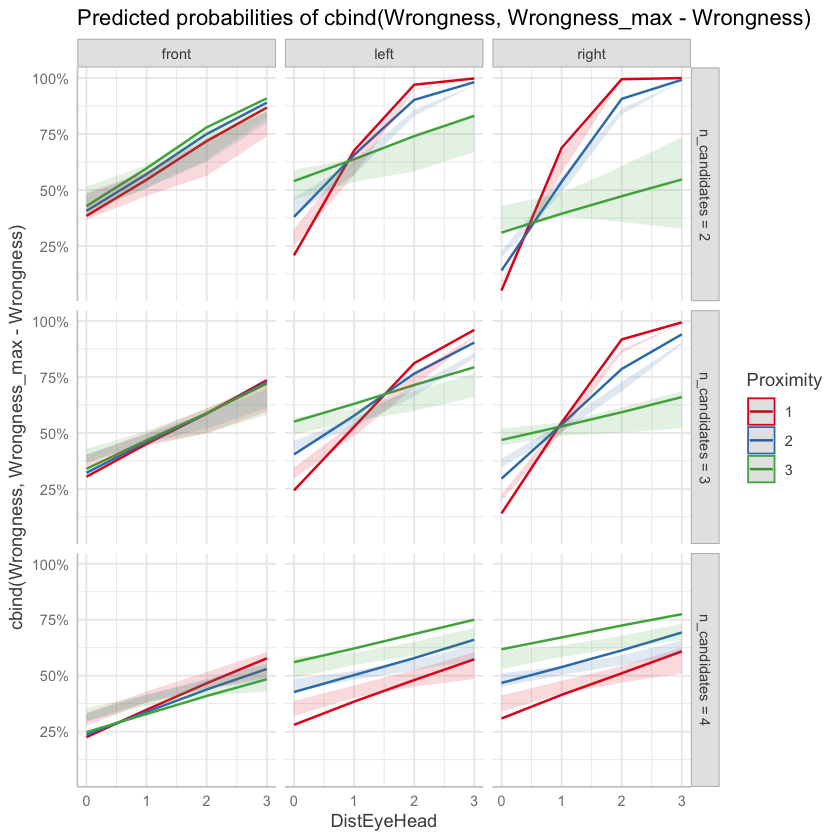

In [84]:
plot(ggpredict(
  m_dist, 
  terms = c("DistEyeHead [all]", "Proximity [all]", "Angle [all]", "n_candidates [all]"),
  bias_correction = TRUE
))

Warning message:
“For this model type, `marginaleffects` only takes into account the uncertainty in fixed-effect parameters. This is often appropriate when `re.form=NA`, but may be surprising to users who set `re.form=NULL` (default) or to some other value. Call `options(marginaleffects_safe = FALSE)` to silence this warning.”


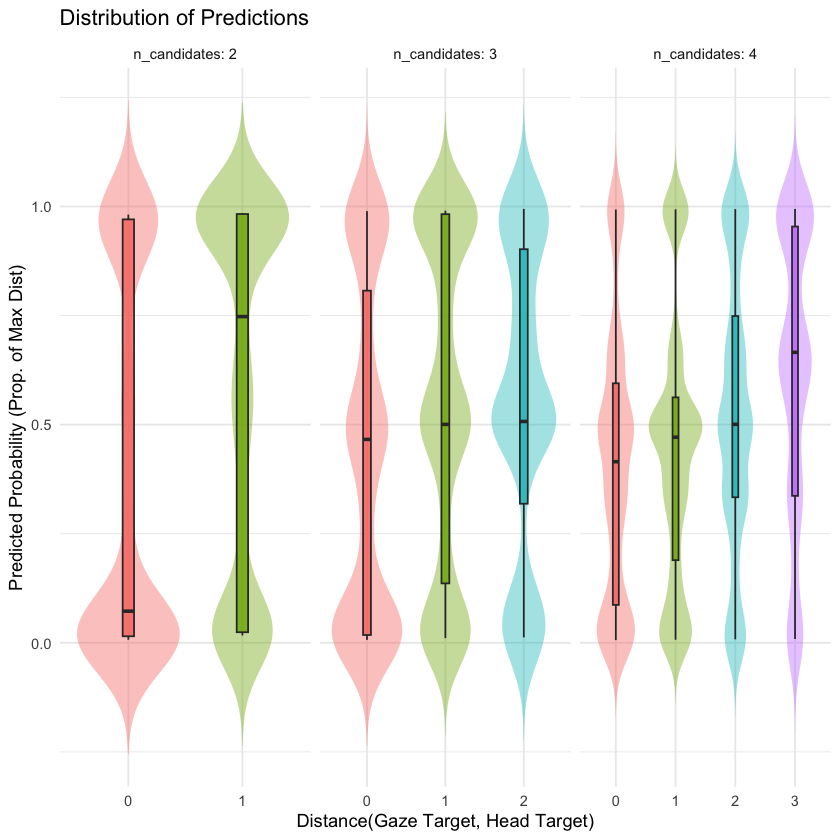

In [65]:
valid_grid <- df_unnatural %>%
    distinct(Proximity, Angle, DistEyeHead, n_candidates, offset_wrongness, Stimulus_ID, Prompt_ID, Candidates)
preds <- predictions(m_dist, newdata = valid_grid)

preds$DistEyeHead <- as.factor(preds$DistEyeHead)

ggplot(preds, aes(x = DistEyeHead, y = estimate, fill = DistEyeHead)) +
  # 1. The Violin: Shows the density/distribution of predictions across items
  geom_violin(trim = FALSE, alpha = 0.4, color = NA) +
  
  # 2. (Optional) The Boxplot: Adds a summary (median/IQR) inside the violin
  geom_boxplot(width = 0.1, outlier.shape = NA, alpha = 0.8) +
  
  # 3. (Optional) Jitter: Shows the actual individual item predictions
  # Useful if you don't have thousands of points
#  geom_jitter(width = 0.1, alpha = 0.2, size = 0.1) +

  # Facet by n_candidates to separate the conditions
  facet_wrap(~n_candidates, labeller = label_both, scales = "free_x") +
  
  labs(
    x = "Distance(Gaze Target, Head Target)",
    y = "Predicted Probability (Prop. of Max Dist)",
    title = "Distribution of Predictions",
  ) +
  theme_minimal() +
  theme(legend.position = "none") # Hide legend if x-axis is already labeled

Warning message:
“For this model type, `marginaleffects` only takes into account the uncertainty in fixed-effect parameters. This is often appropriate when `re.form=NA`, but may be surprising to users who set `re.form=NULL` (default) or to some other value. Call `options(marginaleffects_safe = FALSE)` to silence this warning.”
Warning message:
“For this model type, `marginaleffects` only takes into account the uncertainty in fixed-effect parameters. This is often appropriate when `re.form=NA`, but may be surprising to users who set `re.form=NULL` (default) or to some other value. Call `options(marginaleffects_safe = FALSE)` to silence this warning.”
Warning message:
“For this model type, `marginaleffects` only takes into account the uncertainty in fixed-effect parameters. This is often appropriate when `re.form=NA`, but may be surprising to users who set `re.form=NULL` (default) or to some other value. Call `options(marginaleffects_safe = FALSE)` to silence this warning.”


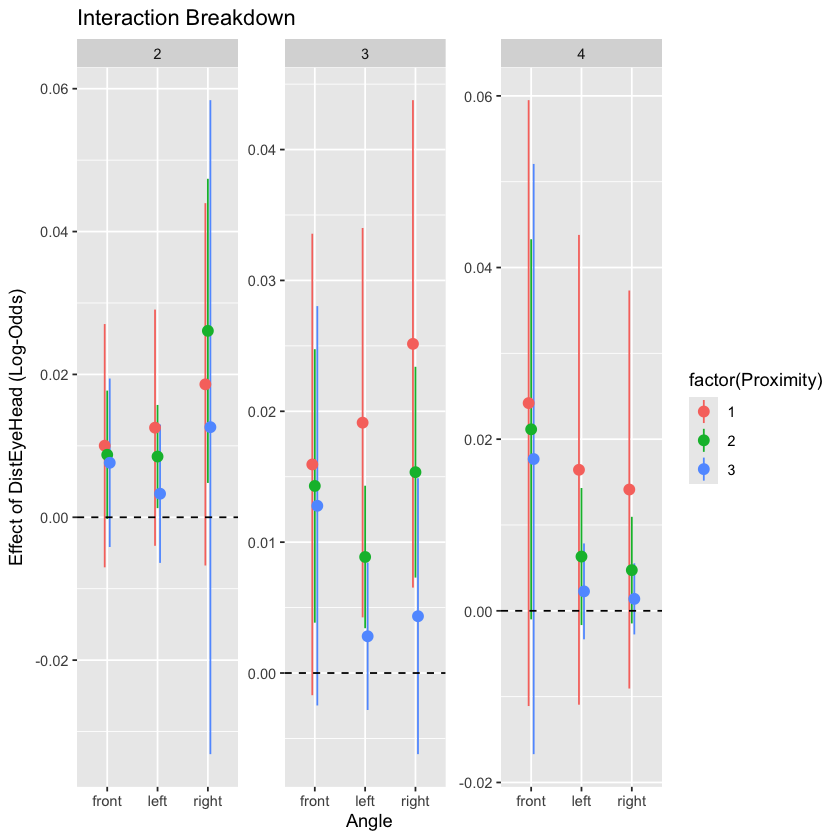

In [66]:
plot_slopes(
  m_dist,
  variables = "DistEyeHead",
  condition = c("Angle", "Proximity", "n_candidates") 
) +
  geom_hline(yintercept = 0, linetype = "dashed") + # Adds a line at 0 (null effect)
  labs(y = "Effect of DistEyeHead (Log-Odds)", title = "Interaction Breakdown")

In [67]:
avg_slopes(m_dist, variables = "DistEyeHead", by = "Proximity")

Warning message:
“For this model type, `marginaleffects` only takes into account the uncertainty in fixed-effect parameters. This is often appropriate when `re.form=NA`, but may be surprising to users who set `re.form=NULL` (default) or to some other value. Call `options(marginaleffects_safe = FALSE)` to silence this warning.”


term,contrast,Proximity,estimate,std.error,statistic,p.value,s.value,conf.low,conf.high
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
DistEyeHead,dY/dX,1,0.13377817,0.02682284,4.987473,6.117429e-07,20.640571,0.081206373,0.1863500
DistEyeHead,dY/dX,2,0.09328982,0.01760324,5.299583,1.160672e-07,23.038536,0.058788114,0.1277915
DistEyeHead,dY/dX,3,0.06083128,0.02694056,2.257981,2.394684e-02,5.384021,0.008028746,0.1136338


In [68]:
avg_slopes(m_dist, variables = "DistEyeHead", by = "Angle", hypothesis = ~ pairwise)

Warning message:
“For this model type, `marginaleffects` only takes into account the uncertainty in fixed-effect parameters. This is often appropriate when `re.form=NA`, but may be surprising to users who set `re.form=NULL` (default) or to some other value. Call `options(marginaleffects_safe = FALSE)` to silence this warning.”


hypothesis,estimate,std.error,statistic,p.value,s.value,conf.low,conf.high
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
(left) - (front),-0.05603173,0.04587381,-1.2214318,0.2219226,2.171872,-0.14594275,0.03387928
(right) - (front),-0.03219332,0.04589285,-0.7014889,0.4829980,1.049911,-0.12214164,0.05775500
(right) - (left),0.02383841,0.03299950,0.7223871,0.4700565,1.089094,-0.04083942,0.08851624


### Test 3: Fix the HeadTarget. As the GazeTarget moves farther away from the HeadTarget, do their responses move farther away from the HeadTarget?
Take results in the Congruent and Incongruent Conditions. Fit “cbind(DistToHeadTarget, MaxDistToHeadTarget - DistToHeadTarget) ~ Proximity * Angle * #Objects * DistEyeHead + (1|Random Effects)” with offset being the chance baseline logit(ExpectedDistToHeadTarget / MaxDistToHeadTarget). If the marginal slope indicates that as DistEyeHead increases, the relative DistToHeadTarget also increases, then the answer is yes.

In [69]:
m_head <- glmer(cbind(DistToHeadTarget, MaxDistToHeadTarget - DistToHeadTarget) ~ scale(Proximity, scale=FALSE) * Angle * scale(n_candidates, scale = FALSE) * scale(DistEyeHead, scale = FALSE) + offset(offset_wrongness_head) + (1|Stimulus_ID) + (1|Prompt_ID) + (1 | Candidates), data = df_unnatural, family = binomial, control = strict_control)

In [72]:
m_head_sim <- glmer(cbind(DistToHeadTarget, MaxDistToHeadTarget - DistToHeadTarget) ~ scale(Proximity, scale=FALSE) + Angle + scale(n_candidates, scale = FALSE) + scale(DistEyeHead, scale = FALSE) + offset(offset_wrongness_head) + (1|Stimulus_ID) + (1|Prompt_ID) + (1 | Candidates), data = df_unnatural, family = binomial, control = strict_control)
anova(m_head, m_head_sim)

,npar,AIC,BIC,logLik,-2*log(L),Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
m_head_sim,9,17765.92,17835.29,-8873.961,17747.92,NA,NA,NA
m_head,27,17780.08,17988.20,-8863.041,17726.08,21.83979,18,0.2391756


In [76]:
avg_slopes(m_head_sim, variables = "DistEyeHead")

Warning message:
“For this model type, `marginaleffects` only takes into account the uncertainty in fixed-effect parameters. This is often appropriate when `re.form=NA`, but may be surprising to users who set `re.form=NULL` (default) or to some other value. Call `options(marginaleffects_safe = FALSE)` to silence this warning.”


term,contrast,estimate,std.error,statistic,p.value,s.value,conf.low,conf.high
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
DistEyeHead,dY/dX,0.007229043,0.01652045,0.4375815,0.6616897,0.5957733,-0.02515044,0.03960853


In [74]:
exp(0.007229043)

[1] 1.007255

Warning message:
“For this model type, `marginaleffects` only takes into account the uncertainty in fixed-effect parameters. This is often appropriate when `re.form=NA`, but may be surprising to users who set `re.form=NULL` (default) or to some other value. Call `options(marginaleffects_safe = FALSE)` to silence this warning.”


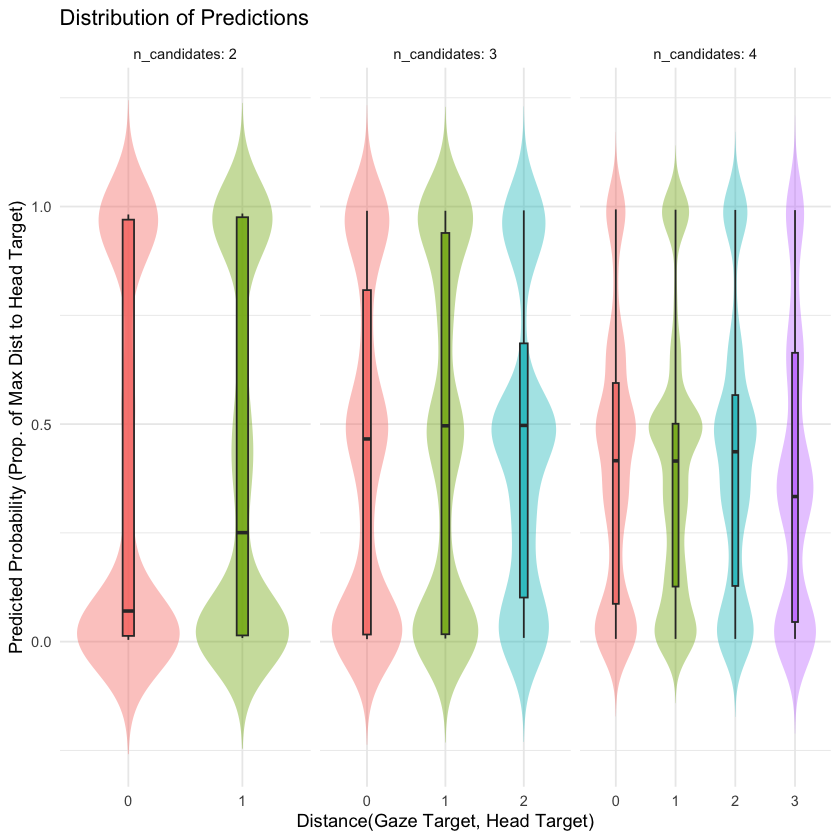

In [77]:
valid_grid <- df_unnatural %>%
    distinct(Angle, DistEyeHead, n_candidates, Proximity, offset_wrongness_head, Stimulus_ID, Prompt_ID, Candidates)
preds <- predictions(m_head, newdata = valid_grid)

preds$DistEyeHead <- as.factor(preds$DistEyeHead)
ggplot(preds, aes(x = DistEyeHead, y = estimate, fill = DistEyeHead)) +
  # 1. The Violin: Shows the density/distribution of predictions across items
  geom_violin(trim = FALSE, alpha = 0.4, color = NA) +
  
  # 2. (Optional) The Boxplot: Adds a summary (median/IQR) inside the violin
  geom_boxplot(width = 0.1, outlier.shape = NA, alpha = 0.8) +
  
  # 3. (Optional) Jitter: Shows the actual individual item predictions
  # Useful if you don't have thousands of points
#  geom_jitter(width = 0.1, alpha = 0.2, size = 0.1) +

  # Facet by n_candidates to separate the conditions
  facet_wrap(~n_candidates, labeller = label_both, scales = "free_x") +
  
  labs(
    x = "Distance(Gaze Target, Head Target)",
    y = "Predicted Probability (Prop. of Max Dist to Head Target)",
    title = "Distribution of Predictions",
  ) +
  theme_minimal() +
  theme(legend.position = "none") # Hide legend if x-axis is already labeled

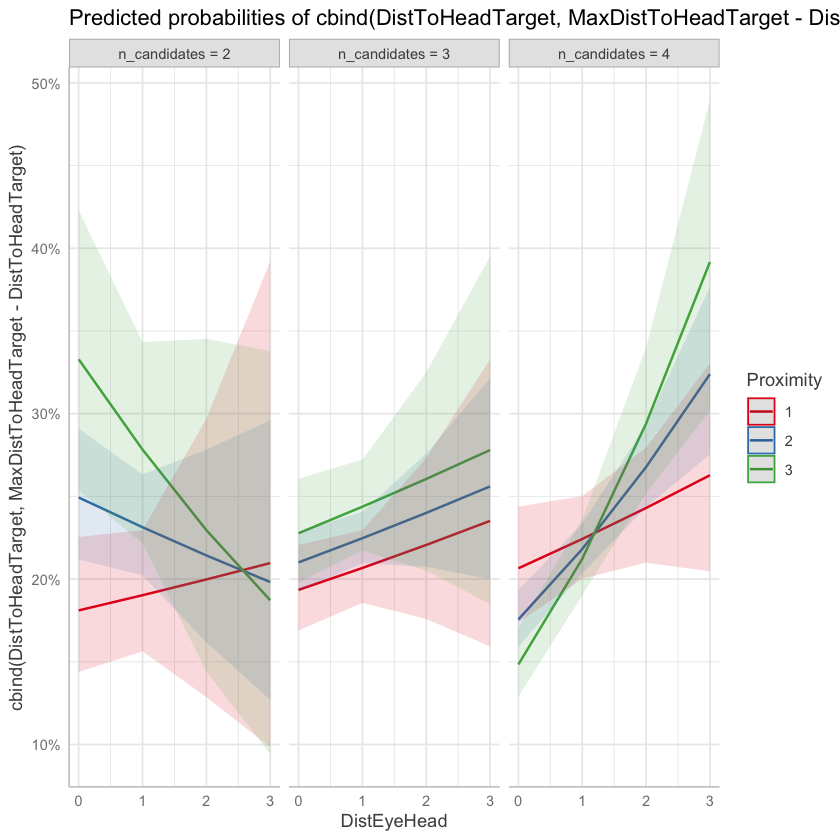

In [78]:
plot(ggpredict(
  m_head, 
  terms = c("DistEyeHead [all]", "Proximity [all]", "n_candidates [all]")
))

In [82]:
avg_slopes(m_head, variables = "DistEyeHead", by = "n_candidates")

Warning message:
“For this model type, `marginaleffects` only takes into account the uncertainty in fixed-effect parameters. This is often appropriate when `re.form=NA`, but may be surprising to users who set `re.form=NULL` (default) or to some other value. Call `options(marginaleffects_safe = FALSE)` to silence this warning.”


term,contrast,n_candidates,estimate,std.error,statistic,p.value,s.value,conf.low,conf.high
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
DistEyeHead,dY/dX,2,0.0157055850,0.03071536,0.51132681,0.6091222,0.71519632,-0.04449541,0.07590658
DistEyeHead,dY/dX,3,0.0366547367,0.02394611,1.53071761,0.1258392,2.99034668,-0.01027878,0.08358826
DistEyeHead,dY/dX,4,-0.0008176548,0.02285426,-0.03577691,0.9714602,0.04177314,-0.04561118,0.04397587


### Test 4: How exactly does Frequency(response=head target) correlate with distance(head target, gaze target)? 
This will distinguish between Possibilities 4 & 5. Possibility 4 predicts that Frequency(response=head target) correlates negatively with distance(head target, gaze target), while Possibility 5 predicts that Frequency(response=head target) jumps down only when distance(head target, gaze target) goes from 0 to 1, but stays the same after that. If the relation turns out not to be a negative correlation, then these two explanations are incomplete. 

Take results in the Congruent and Incongruent Conditions with #Objects greater than 2. Fit “IsHeadTarget ~ Proximity * View * #Object  * DistEyeHead + (1|Random Effects).” Here, DistEyeHead is treated as categorical. Separately looking at #Object=3 and 4, the marginal means of IsHeadTarget for DistEyeHead=1 and 2 (or 1, 2, and 3 for #Object=4) are not significantly different from each other, but are all significantly lower than when DistEyeHead=0, then Possibility 5 is supported. Otherwise, if the marginal mean in general decreases, then Possibility 4 is supported.

In [88]:
m_3obj <- glmer(as.factor(IsHeadTarget) ~ scale(Proximity, scale=FALSE) * Angle * as.factor(DistEyeHead) + offset(offset_accuracy) + (1 | Stimulus_ID) + (1 | Prompt_ID), data = df_unnatural[df_unnatural$n_candidates == 3, ], family = binomial, control = strict_control)

In [89]:
m_4obj <- glmer(as.factor(IsHeadTarget) ~ scale(Proximity, scale=FALSE) * Angle * as.factor(DistEyeHead) + offset(offset_accuracy) + (1 | Stimulus_ID) + (1 | Prompt_ID), data = df_unnatural[df_unnatural$n_candidates == 4, ], family = binomial, control = strict_control)

In [102]:
avg_predictions(m_3obj, variables = "DistEyeHead",)
avg_predictions(m_4obj, variables = "DistEyeHead",)

Warning message:
“For this model type, `marginaleffects` only takes into account the uncertainty in fixed-effect parameters. This is often appropriate when `re.form=NA`, but may be surprising to users who set `re.form=NULL` (default) or to some other value. Call `options(marginaleffects_safe = FALSE)` to silence this warning.”


DistEyeHead,estimate,std.error,statistic,p.value,s.value,conf.low,conf.high,df
<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0,0.3298732,0.04158589,7.932336,2.150616e-15,48.72417,0.2483664,0.4113801,Inf
1,0.5305172,0.03469154,15.292411,8.591000e-53,172.95936,0.4625231,0.5985114,Inf
2,0.2924609,0.04723645,6.191424,5.962325e-10,30.64341,0.1998791,0.3850426,Inf


Warning message:
“For this model type, `marginaleffects` only takes into account the uncertainty in fixed-effect parameters. This is often appropriate when `re.form=NA`, but may be surprising to users who set `re.form=NULL` (default) or to some other value. Call `options(marginaleffects_safe = FALSE)` to silence this warning.”


DistEyeHead,estimate,std.error,statistic,p.value,s.value,conf.low,conf.high,df
<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0,0.2936829,0.03451787,8.508141,1.767445e-17,55.651112,0.2260291,0.3613366,Inf
1,0.3211484,0.03803585,8.443307,3.084842e-17,54.847581,0.2465995,0.3956973,Inf
2,0.3023370,0.03955068,7.644294,2.100943e-14,45.435956,0.2248191,0.3798550,Inf
3,0.3382656,0.12155760,2.782760,5.389864e-03,7.535535,0.1000171,0.5765142,Inf


In [90]:
avg_predictions(m_3obj, variables = "DistEyeHead", hypothesis = ~ pairwise)
avg_predictions(m_4obj, variables = "DistEyeHead", hypothesis = ~ pairwise)

Warning message:
“For this model type, `marginaleffects` only takes into account the uncertainty in fixed-effect parameters. This is often appropriate when `re.form=NA`, but may be surprising to users who set `re.form=NULL` (default) or to some other value. Call `options(marginaleffects_safe = FALSE)` to silence this warning.”


hypothesis,estimate,std.error,statistic,p.value,s.value,conf.low,conf.high,df
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
(1) - (0),0.20064402,0.04790639,4.1882518,2.811115e-05,15.118498,0.1067492,0.29453881,Inf
(2) - (0),-0.03741234,0.05507239,-0.6793302,4.969287e-01,1.008889,-0.1453522,0.07052757,Inf
(2) - (1),-0.23805635,0.05368260,-4.4345161,9.227931e-06,16.725561,-0.3432723,-0.13284039,Inf


Warning message:
“For this model type, `marginaleffects` only takes into account the uncertainty in fixed-effect parameters. This is often appropriate when `re.form=NA`, but may be surprising to users who set `re.form=NULL` (default) or to some other value. Call `options(marginaleffects_safe = FALSE)` to silence this warning.”


hypothesis,estimate,std.error,statistic,p.value,s.value,conf.low,conf.high,df
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
(1) - (0),0.027465505,0.04159946,0.6602370,0.5091017,0.9739741,-0.05406794,0.10899895,Inf
(2) - (0),0.008654177,0.04407550,0.1963489,0.8443371,0.2441090,-0.07773222,0.09504058,Inf
(3) - (0),0.044582776,0.12161692,0.3665837,0.7139296,0.4861463,-0.19378200,0.28294755,Inf
(2) - (1),-0.018811328,0.04484382,-0.4194854,0.6748614,0.5673369,-0.10670360,0.06908094,Inf
(3) - (1),0.017117271,0.12158324,0.1407864,0.8880387,0.1713056,-0.22118150,0.25541604,Inf
(3) - (2),0.035928599,0.12273893,0.2927237,0.7697333,0.3775694,-0.20463529,0.27649249,Inf


Warning message:
“For this model type, `marginaleffects` only takes into account the uncertainty in fixed-effect parameters. This is often appropriate when `re.form=NA`, but may be surprising to users who set `re.form=NULL` (default) or to some other value. Call `options(marginaleffects_safe = FALSE)` to silence this warning.”


Warning message:
“For this model type, `marginaleffects` only takes into account the uncertainty in fixed-effect parameters. This is often appropriate when `re.form=NA`, but may be surprising to users who set `re.form=NULL` (default) or to some other value. Call `options(marginaleffects_safe = FALSE)` to silence this warning.”


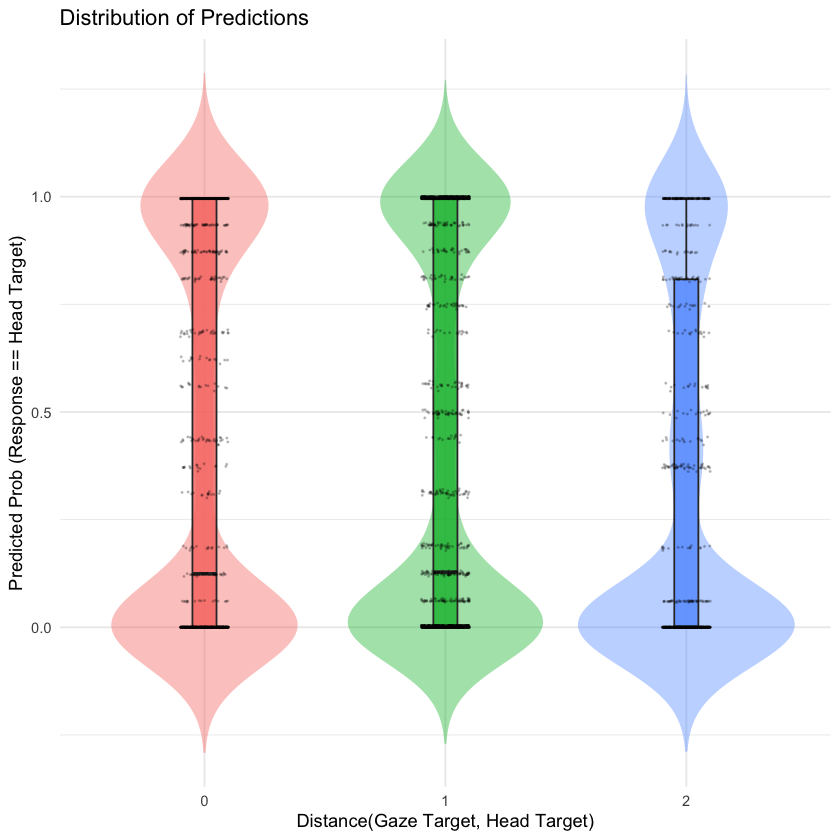

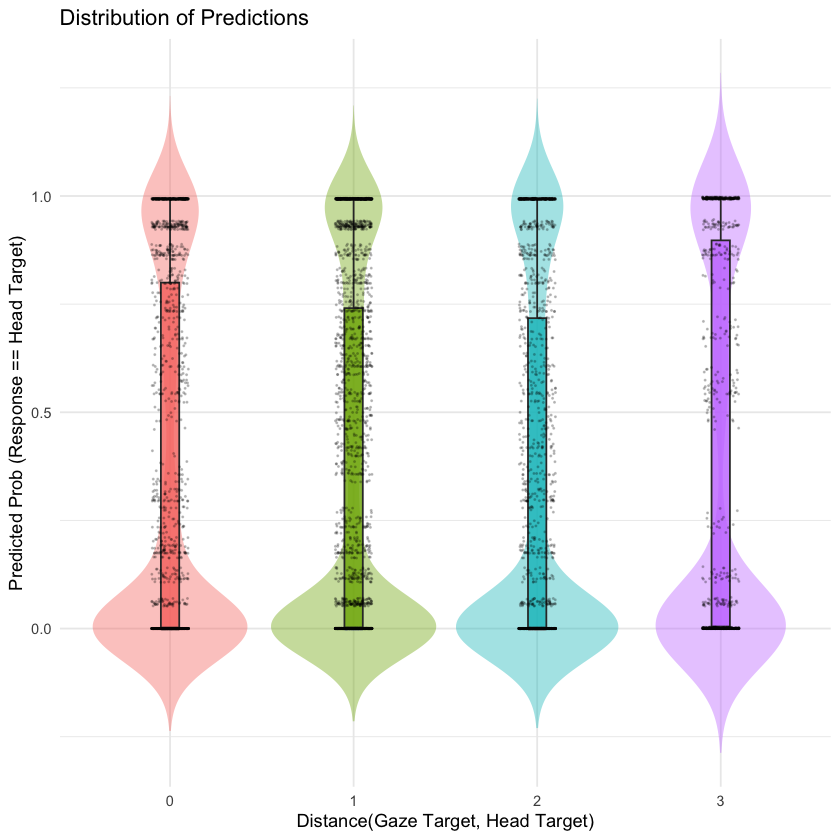

In [96]:
plot_head_preds <- function(model, data, x_var = "DistEyeHead", facet_var = NULL) {
  
  # 1. Define the columns we absolutely need for the prediction grid
  #    (Predictors + Random Effect Group + Offset)
  needed_cols <- c(x_var, "Candidates", "Proximity", "Angle", "offset_accuracy", "Stimulus_ID", "Prompt_ID")
  if (!is.null(facet_var)) needed_cols <- c(needed_cols, facet_var)
  
  # 2. Create the valid_grid
  #    We use distinct() to avoid predicting on 20,000 rows if we only need
  #    unique condition+candidate combinations.
  valid_grid <- data %>%
    select(all_of(intersect(needed_cols, names(data)))) %>%
    distinct()
  
  # 3. Generate Predictions
  #    type="response" ensures we get probabilities (0-1)
  preds <- predictions(model, newdata = valid_grid, type = "response")
  
  # 4. Prepare for plotting
  #    Convert x_var to factor so violin plots work properly
  preds[[x_var]] <- as.factor(preds[[x_var]])
  
  # 5. Build the Plot
  p <- ggplot(preds, aes(x = .data[[x_var]], y = estimate, fill = .data[[x_var]])) +
    # The Violin: Density across items
    geom_violin(trim = FALSE, alpha = 0.4, color = NA) +
    
    # The Boxplot: Summary stats
    geom_boxplot(width = 0.1, outlier.shape = NA, alpha = 0.8) +
    
    # Jitter: Individual item points
    geom_jitter(width = 0.1, alpha = 0.2, size = 0.2) +
    
    # Labels
    labs(
      x = "Distance(Gaze Target, Head Target)",
      y = "Predicted Prob (Response == Head Target)",
      title = "Distribution of Predictions"
    ) +
    theme_minimal() +
    theme(legend.position = "none")
  
  # 6. Add Faceting conditionally
  if (!is.null(facet_var)) {
    p <- p + facet_wrap(as.formula(paste("~", facet_var)), 
                        labeller = label_both, 
                        scales = "free_x")
  }
  
  return(p)
}

plot_head_preds(
  model = m_3obj, 
  data = df_unnatural[df_unnatural$n_candidates == 3, ]
)
plot_head_preds(
  model = m_4obj, 
  data = df_unnatural[df_unnatural$n_candidates == 4, ]
)

Ignoring unknown labels:
• linetype : "DistEyeHead"
• shape : "DistEyeHead"


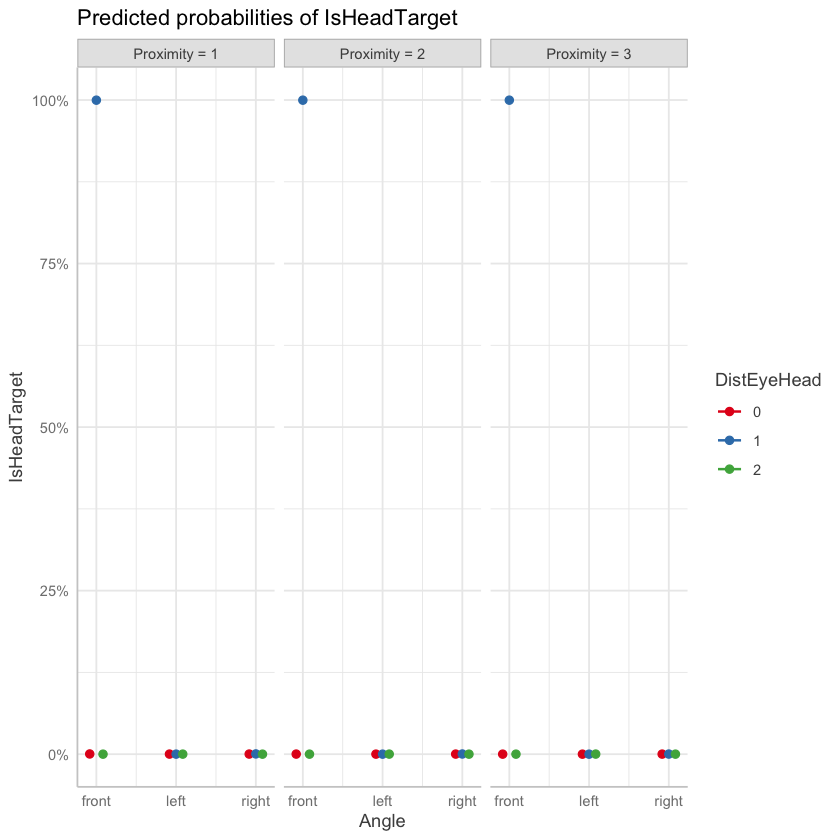

In [100]:
plot(ggpredict(
  m_3obj, 
  terms = c("Angle [all]", "DistEyeHead [all]", "Proximity [all]")
))

Ignoring unknown labels:
• linetype : "DistEyeHead"
• shape : "DistEyeHead"


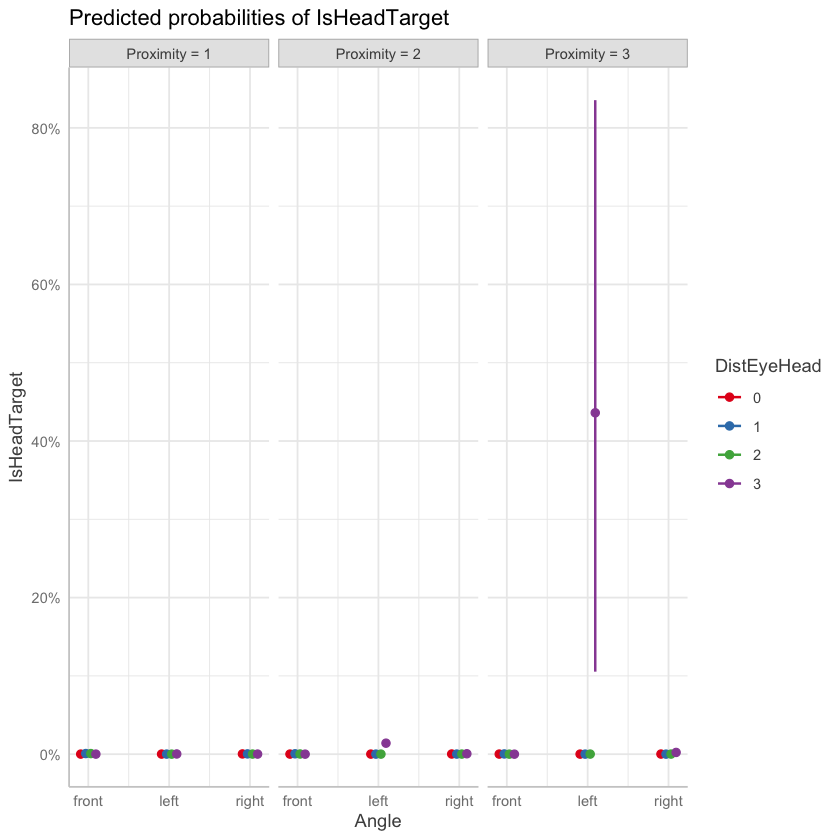

In [101]:
plot(ggpredict(
  m_4obj, 
  terms = c("Angle [all]", "DistEyeHead [all]", "Proximity [all]")
))

## Exploratory

In [ ]:
df_view <- df_B %>%
  mutate(DistEyeHead = factor(replace_na(DistEyeHead, -1)))

### An Overview

In [ ]:
m_plot <- glmer(cbind(Wrongness, Wrongness_max - Wrongness) ~ Proximity_c * Angle * n_candidates_c * Condition + offset(offset_wrongness) + (1 | Stimulus_ID) + (1 | Prompt_ID) + (1 | Site) + (1 | Site: Candidates), data = df_B, family = binomial, control = strict_control)

In [ ]:
m_plot

Warning message:
“For this model type, `marginaleffects` only takes into account the uncertainty in fixed-effect parameters. This is often appropriate when `re.form=NA`, but may be surprising to users who set `re.form=NULL` (default) or to some other value. Call `options(marginaleffects_safe = FALSE)` to silence this warning.”
Warning message:
“For this model type, `marginaleffects` only takes into account the uncertainty in fixed-effect parameters. This is often appropriate when `re.form=NA`, but may be surprising to users who set `re.form=NULL` (default) or to some other value. Call `options(marginaleffects_safe = FALSE)` to silence this warning.”


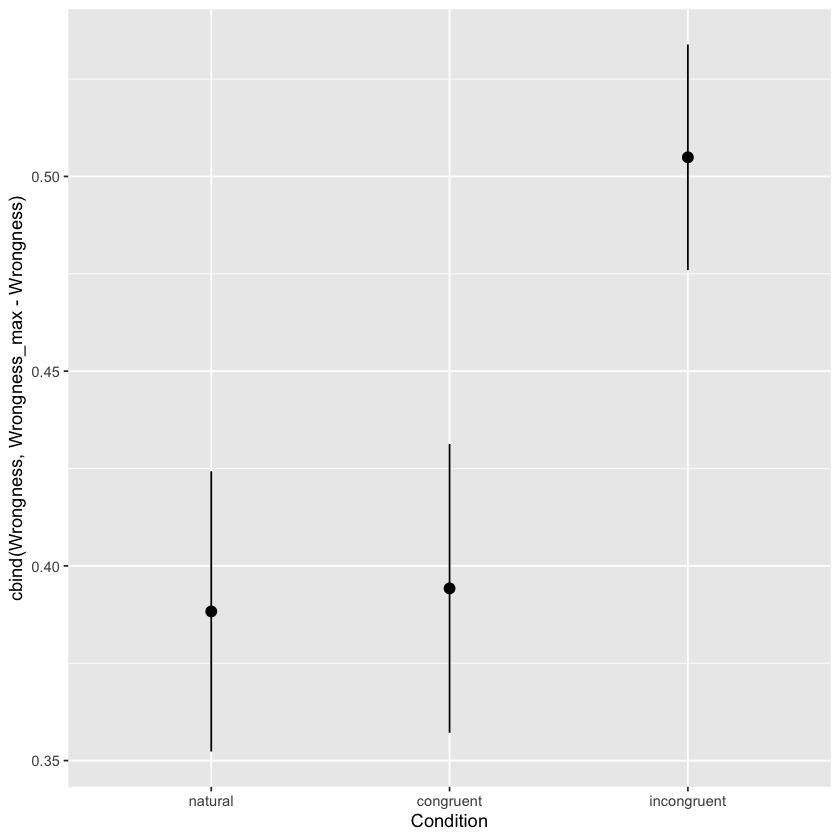

In [ ]:
plot_predictions(m_plot, by = c("Condition"))

Warning message:
“For this model type, `marginaleffects` only takes into account the uncertainty in fixed-effect parameters. This is often appropriate when `re.form=NA`, but may be surprising to users who set `re.form=NULL` (default) or to some other value. Call `options(marginaleffects_safe = FALSE)` to silence this warning.”
Warning message:
“For this model type, `marginaleffects` only takes into account the uncertainty in fixed-effect parameters. This is often appropriate when `re.form=NA`, but may be surprising to users who set `re.form=NULL` (default) or to some other value. Call `options(marginaleffects_safe = FALSE)` to silence this warning.”
Warning message:
“For this model type, `marginaleffects` only takes into account the uncertainty in fixed-effect parameters. This is often appropriate when `re.form=NA`, but may be surprising to users who set `re.form=NULL` (default) or to some other value. Call `options(marginaleffects_safe = FALSE)` to silence this warning.”
Warning messa

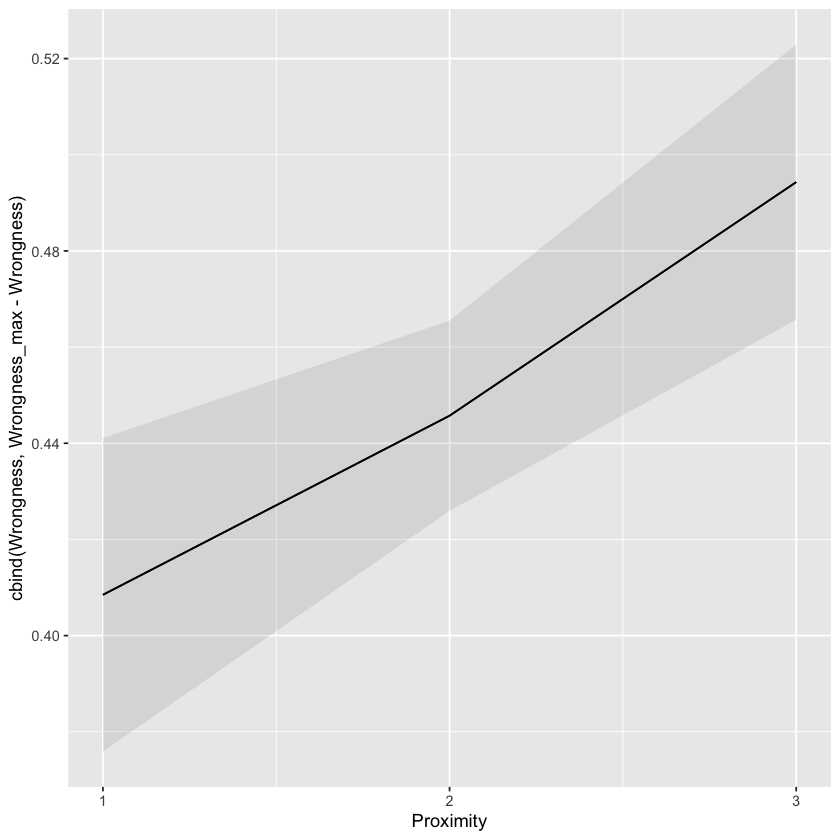

Warning message:
“For this model type, `marginaleffects` only takes into account the uncertainty in fixed-effect parameters. This is often appropriate when `re.form=NA`, but may be surprising to users who set `re.form=NULL` (default) or to some other value. Call `options(marginaleffects_safe = FALSE)` to silence this warning.”
Warning message:
“For this model type, `marginaleffects` only takes into account the uncertainty in fixed-effect parameters. This is often appropriate when `re.form=NA`, but may be surprising to users who set `re.form=NULL` (default) or to some other value. Call `options(marginaleffects_safe = FALSE)` to silence this warning.”


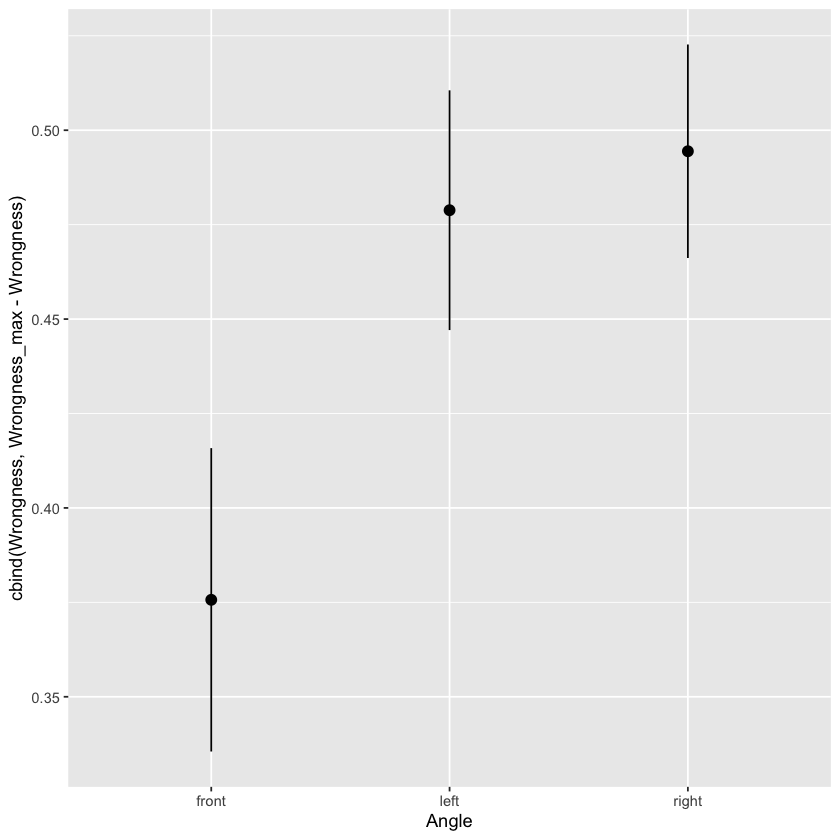

Warning message:
“For this model type, `marginaleffects` only takes into account the uncertainty in fixed-effect parameters. This is often appropriate when `re.form=NA`, but may be surprising to users who set `re.form=NULL` (default) or to some other value. Call `options(marginaleffects_safe = FALSE)` to silence this warning.”
Warning message:
“For this model type, `marginaleffects` only takes into account the uncertainty in fixed-effect parameters. This is often appropriate when `re.form=NA`, but may be surprising to users who set `re.form=NULL` (default) or to some other value. Call `options(marginaleffects_safe = FALSE)` to silence this warning.”


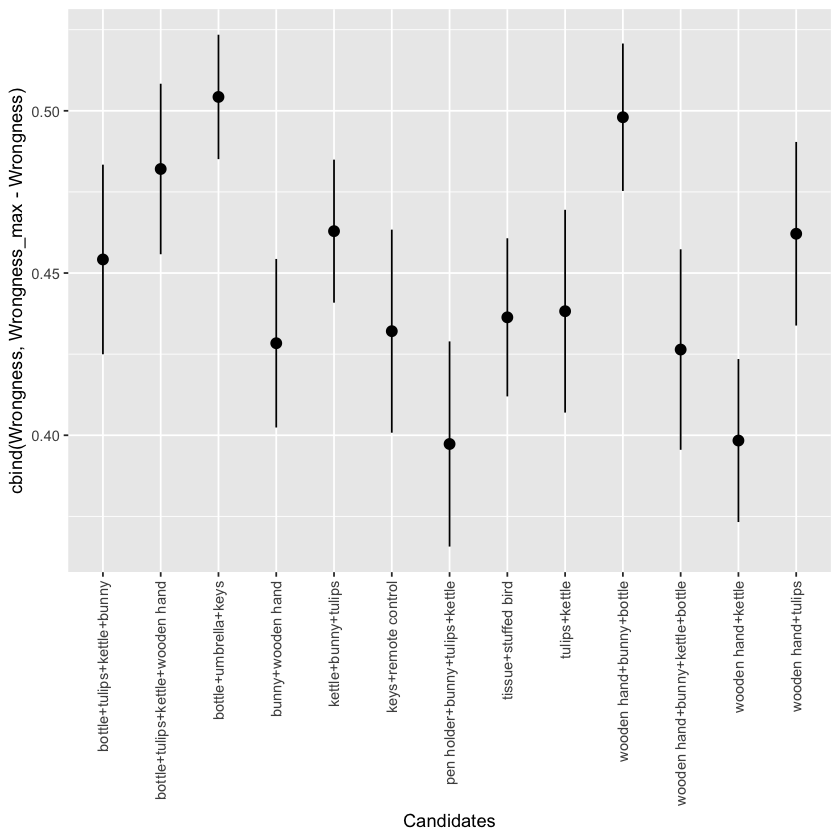

Warning message:
“For this model type, `marginaleffects` only takes into account the uncertainty in fixed-effect parameters. This is often appropriate when `re.form=NA`, but may be surprising to users who set `re.form=NULL` (default) or to some other value. Call `options(marginaleffects_safe = FALSE)` to silence this warning.”
Warning message:
“For this model type, `marginaleffects` only takes into account the uncertainty in fixed-effect parameters. This is often appropriate when `re.form=NA`, but may be surprising to users who set `re.form=NULL` (default) or to some other value. Call `options(marginaleffects_safe = FALSE)` to silence this warning.”


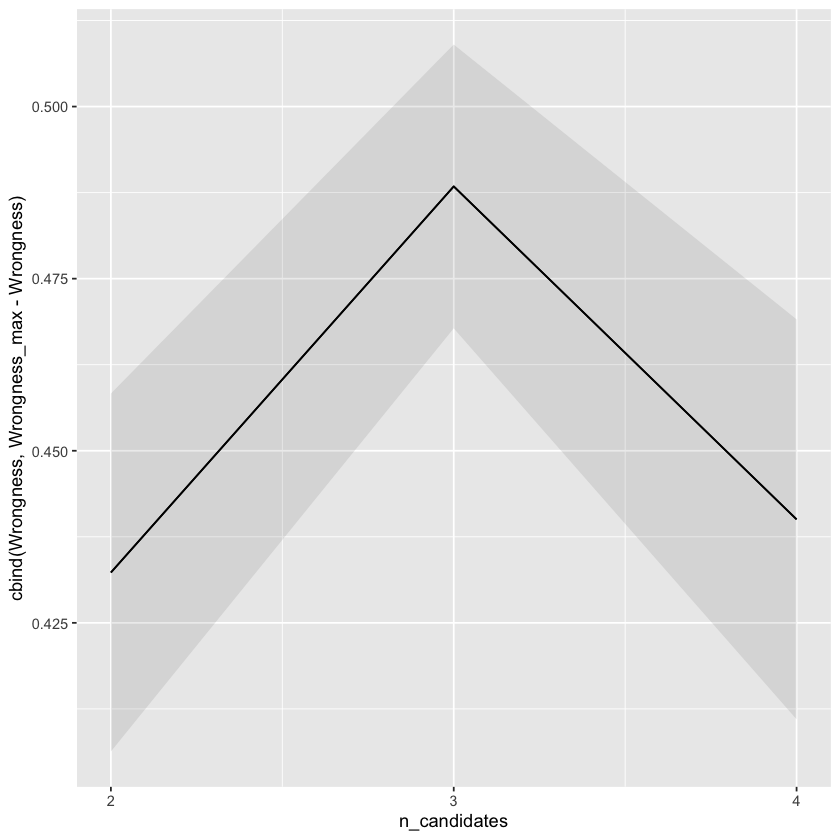

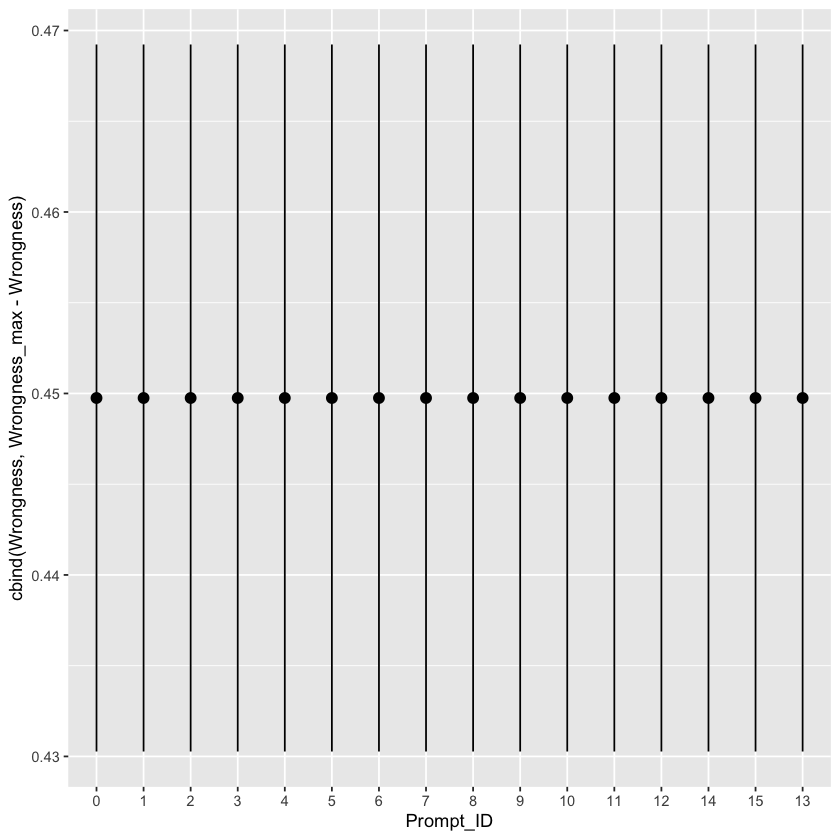

In [ ]:
plot_predictions(m_plot, by = c("Proximity")) +
    scale_x_continuous(breaks = c(1, 2, 3))
plot_predictions(m_plot, by = c("Angle"))
plot_predictions(m_plot, by = c("Candidates")) +
    theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1))
plot_predictions(m_plot, by = c("n_candidates"))+ 
    scale_x_continuous(breaks = c(2, 3, 4))
plot_predictions(m_plot, by = c("Prompt_ID"))

### Look at View effects in different conditions

In [ ]:
m_prompt <- glmer(cbind(Wrongness, Wrongness_max - Wrongness) ~ Prompt_ID * Angle * DistEyeHead * Proximity_c + offset(offset_wrongness) + (1 | Stimulus_ID) + (1 | Candidates), data = df_view, family = binomial, control = strict_control)

Warning message in commonArgs(par, fn, control, environment()):
“maxfun < 10 * length(par)^2 is not recommended.”


Warning message:
“For this model type, `marginaleffects` only takes into account the uncertainty in fixed-effect parameters. This is often appropriate when `re.form=NA`, but may be surprising to users who set `re.form=NULL` (default) or to some other value. Call `options(marginaleffects_safe = FALSE)` to silence this warning.”
Warning message:
“For this model type, `marginaleffects` only takes into account the uncertainty in fixed-effect parameters. This is often appropriate when `re.form=NA`, but may be surprising to users who set `re.form=NULL` (default) or to some other value. Call `options(marginaleffects_safe = FALSE)` to silence this warning.”


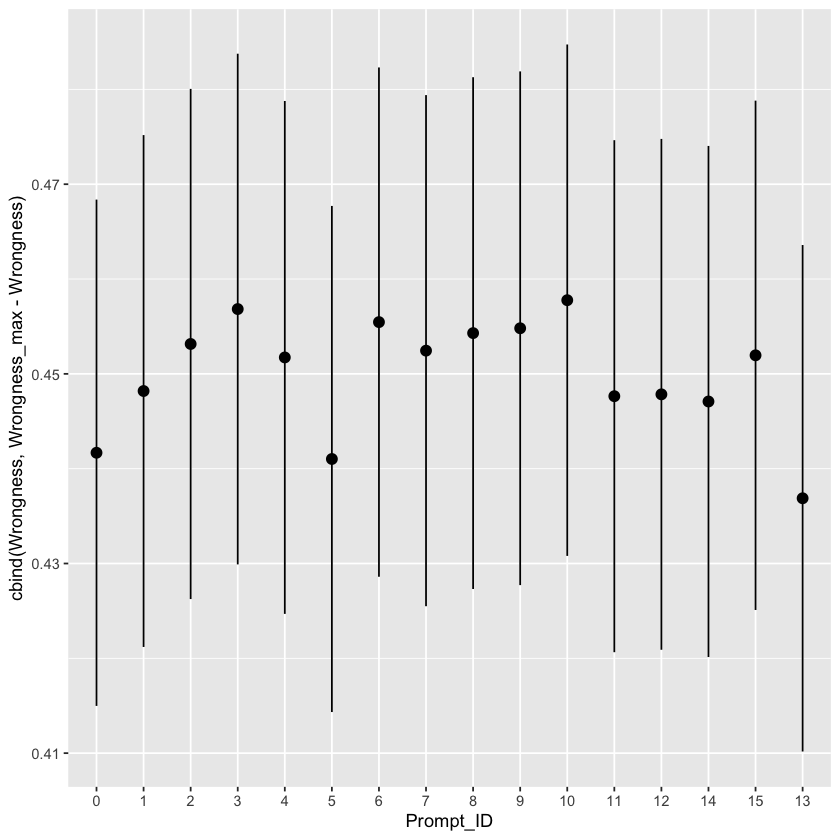

In [ ]:
plot_predictions(m_prompt, by = c("Prompt_ID"))

In [ ]:
model_view_c <- glmer(cbind(Wrongness, Wrongness_max - Wrongness) ~ scale(Proximity, scale=FALSE) * Angle * scale(n_candidates, scale = FALSE) * DistEyeHead + offset(offset_wrongness) + (1 | Stimulus_ID) + (1 | Prompt_ID) + (1 | Candidates), data = df_view, family = binomial, control = strict_control)

fixed-effect model matrix is rank deficient so dropping 6 columns / coefficients



In [ ]:

  
model_view <- glmer(cbind(Wrongness, Wrongness_max - Wrongness) ~ scale(Proximity, scale=FALSE) + Angle + scale(n_candidates, scale = FALSE) + DistEyeHead + offset(offset_wrongness) + (1 | Stimulus_ID) + (1 | Prompt_ID) + (1 | Candidates), data = df_view, family = binomial, control = strict_control)

anova(model_view, model_view_c)

In [ ]:
options(repr.plot.width=10, repr.plot.height=6)
plot_slopes(
  model_view_c,
  variables = "Proximity",
  condition = c("DistEyeHead", "n_candidates", "Angle") 
) +
  geom_hline(yintercept = 0, linetype = "dashed") + # Adds a line at 0 (null effect)
  labs(y = "Effect of Proximity (Log-Odds)", title = "Interaction Breakdown") +
  theme_minimal()

In [ ]:
plot_slopes(
  model_view_c,
  variables = "Angle",
  condition = c("DistEyeHead", "Proximity") 
) +
  geom_hline(yintercept = 0, linetype = "dashed") + # Adds a line at 0 (null effect)
  labs(y = "Effect of Angle (Log-Odds)", title = "Interaction Breakdown") +
  theme_minimal()